# Supervised Learning
## 2.1 Classical ML Models (Logistic Regression & Gradient Boosted Tree)
We decided to mostly use the last-measured value as input feature as this the closest to death and should be most informative. The 4 static values will be kept (for static weight this is the first).

In [3]:
# Simple Feature Prepro
# For each patient: last-measured value of each dynamic variable + static variables

import numpy as np
import pandas as pd
import pickle

# ── Load processed (scaled, imputed) data ────────────────────────────────────
df_train = pd.read_parquet("processed/set_a_processed.parquet")
df_val   = pd.read_parquet("processed/set_b_processed.parquet")
df_test  = pd.read_parquet("processed/set_c_processed.parquet")

DYNAMIC_VARS = sorted([
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2',
    'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH'
])
STATIC_VARS = ['Age', 'Gender', 'Height', 'StaticWeight']
ALL_FEATURES = DYNAMIC_VARS + STATIC_VARS  # 41 features total

def extract_simple_features(df):
    """
    Per patient:
      - Dynamic variables: take the last-measured value (hour 48 row after ffill)
      - Static variables: take as-is (constant across hours)
    Returns one row per patient with features + label.
    """
    last_row = df.sort_values(["RecordID", "hour"]).groupby("RecordID").last().reset_index()
    
    features = last_row[["RecordID"] + ALL_FEATURES].copy()
    labels   = last_row[["RecordID", "In-hospital_death"]].copy()
    
    return features, labels

X_train, y_train = extract_simple_features(df_train)
X_val,   y_val   = extract_simple_features(df_val)
X_test,  y_test  = extract_simple_features(df_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"\nTrain mortality rate: {y_train['In-hospital_death'].mean():.3f}")
print(f"Val   mortality rate: {y_val['In-hospital_death'].mean():.3f}")
print(f"Test  mortality rate: {y_test['In-hospital_death'].mean():.3f}")
print(f"\nNaN in X_train: {X_train[ALL_FEATURES].isna().sum().sum()}")
X_train.head()

Train: (4000, 42), Val: (4000, 42), Test: (4000, 42)
Features (41): ['ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH', 'Age', 'Gender', 'Height', 'StaticWeight']

Train mortality rate: 0.139
Val   mortality rate: 0.142
Test  mortality rate: 0.146

NaN in X_train: 0


,RecordID,ALP,ALT,AST,Albumin,BUN,Bilirubin,Cholesterol,Creatinine,DiasABP,...,TroponinI,TroponinT,Urine,WBC,Weight,pH,Age,Gender,Height,StaticWeight
0,132539,0.666667,0.222222,-0.695652,-0.218305,-0.6875,-0.333333,-0.374775,-0.333333,0.279561,...,-0.318182,-0.185185,1.818182,-0.471044,-0.302991,0.210159,-0.583612,0.0,-0.451583,-2.437098
1,132540,-0.518519,-0.055556,0.217391,-0.446695,0.1250,0.666667,-0.361386,0.666667,-0.704886,...,0.409091,1.259259,1.272727,0.128322,-0.019384,-0.351185,0.669324,1.0,0.353422,0.139491
2,132541,1.074074,2.555556,5.217391,-1.588648,-1.0000,7.000000,1.687192,-1.000000,0.853822,...,0.318182,-0.296296,-0.409091,-0.962831,-1.089358,1.519962,-1.153129,0.0,-0.451583,-0.637229
3,132543,1.074074,-0.944444,-1.260870,3.207554,-0.5625,-1.666667,-0.160545,-0.333333,0.033449,...,-0.113636,-0.074074,4.272727,-0.701569,0.109529,-0.164070,0.213711,1.0,0.670353,0.233071
4,132545,0.037037,-0.166667,-0.130435,0.695258,0.3750,-0.666667,0.107243,0.166667,-0.294700,...,-0.250000,-0.074074,0.000000,-1.177988,-0.822938,0.023044,1.352744,0.0,-0.939658,-2.437098


In [3]:
# ── Logistic Regression ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, roc_curve, precision_recall_curve)

# Prepare arrays (drop RecordID)
X_tr = X_train[ALL_FEATURES].values
X_v  = X_val[ALL_FEATURES].values
X_te = X_test[ALL_FEATURES].values
y_tr = y_train["In-hospital_death"].values
y_v  = y_val["In-hospital_death"].values
y_te = y_test["In-hospital_death"].values

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_tr, y_tr)

lr_proba_val  = lr.predict_proba(X_v)[:, 1]
lr_proba_test = lr.predict_proba(X_te)[:, 1]

print("=== Logistic Regression (default) ===")
print(f"Val  AUROC: {roc_auc_score(y_v, lr_proba_val):.4f}  |  AUPRC: {average_precision_score(y_v, lr_proba_val):.4f}")
print(f"Test AUROC: {roc_auc_score(y_te, lr_proba_test):.4f}  |  AUPRC: {average_precision_score(y_te, lr_proba_test):.4f}")

=== Logistic Regression (default) ===
Val  AUROC: 0.8482  |  AUPRC: 0.5183
Test AUROC: 0.8417  |  AUPRC: 0.4914


In [4]:
# ── Gradient Boosted Tree ────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier

gbt = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
)
gbt.fit(X_tr, y_tr)

gbt_proba_val  = gbt.predict_proba(X_v)[:, 1]
gbt_proba_test = gbt.predict_proba(X_te)[:, 1]

print("=== Gradient Boosted Tree ===")
print(f"Val  AUROC: {roc_auc_score(y_v, gbt_proba_val):.4f}")
print(f"Test AUROC: {roc_auc_score(y_te, gbt_proba_test):.4f}")
print(f"\nVal classification report (threshold=0.5):")
print(classification_report(y_v, (gbt_proba_val >= 0.5).astype(int), target_names=["Survived", "Died"]))

=== Gradient Boosted Tree ===
Val  AUROC: 0.8474
Test AUROC: 0.8443

Val classification report (threshold=0.5):
              precision    recall  f1-score   support

    Survived       0.90      0.96      0.93      3432
        Died       0.58      0.33      0.42       568

    accuracy                           0.87      4000
   macro avg       0.74      0.65      0.68      4000
weighted avg       0.85      0.87      0.86      4000



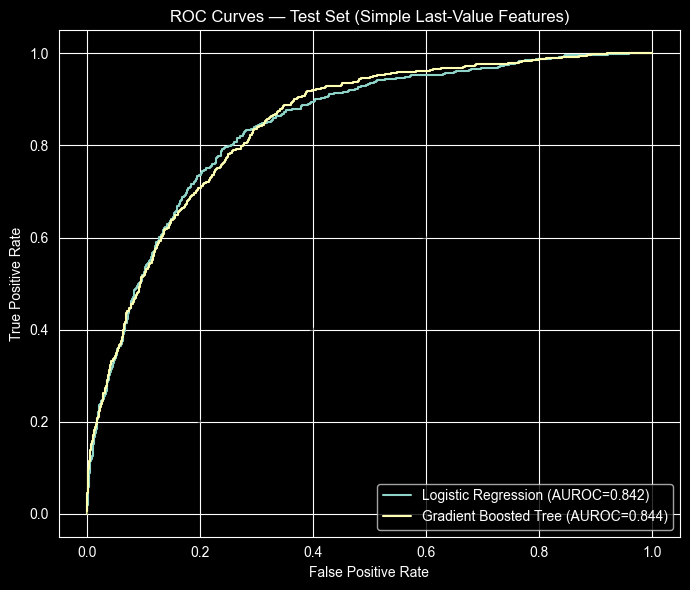

In [5]:
# ── Compare models ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(1, 1, figsize=(7, 6))

for name, proba in [("Logistic Regression", lr_proba_test), ("Gradient Boosted Tree", gbt_proba_test)]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set (Simple Last-Value Features)")
ax.legend()
plt.tight_layout()
plt.show()

## 2.2 Hyperparameter Tuning with GridSearchCV
We use 5-fold stratified cross-validation on the training set, optimizing for AUROC.

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression Grid Search ─────────────────────────────────────────
# Use l1_ratio instead of deprecated penalty parameter:
#   l1_ratio=1 → L1 (Lasso), l1_ratio=0 → L2 (Ridge), 0<l1_ratio<1 → ElasticNet
lr_param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0, 0.25, 0.5, 0.75, 1.0],
    "class_weight": ["balanced", None],
}

lr_gs = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=5000, random_state=42),
    param_grid=lr_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
lr_gs.fit(X_tr, y_tr)

print(f"\n=== Logistic Regression — Best Params ===")
print(lr_gs.best_params_)
print(f"Best CV AUROC: {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== Logistic Regression — Best Params ===
{'C': 0.01, 'class_weight': 'balanced', 'l1_ratio': 0.25}
Best CV AUROC: 0.8293


In [7]:
# ── Gradient Boosted Tree Grid Search ────────────────────────────────────────
gbt_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 6],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.6, 0.7],
    "min_samples_leaf": [15, 20, 25],
}

gbt_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gbt_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)
gbt_gs.fit(X_tr, y_tr)

print(f"\n=== Gradient Boosted Tree — Best Params ===")
print(gbt_gs.best_params_)
print(f"Best CV AUROC: {gbt_gs.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== Gradient Boosted Tree — Best Params ===
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 100, 'subsample': 0.7}
Best CV AUROC: 0.8552


Model             Val AUROC   Val AUPRC   Test AUROC   Test AUPRC
-----------------------------------------------------------------
LR (tuned)           0.8506      0.5276       0.8460       0.4986
GBT (tuned)          0.8502      0.5204       0.8495       0.5270


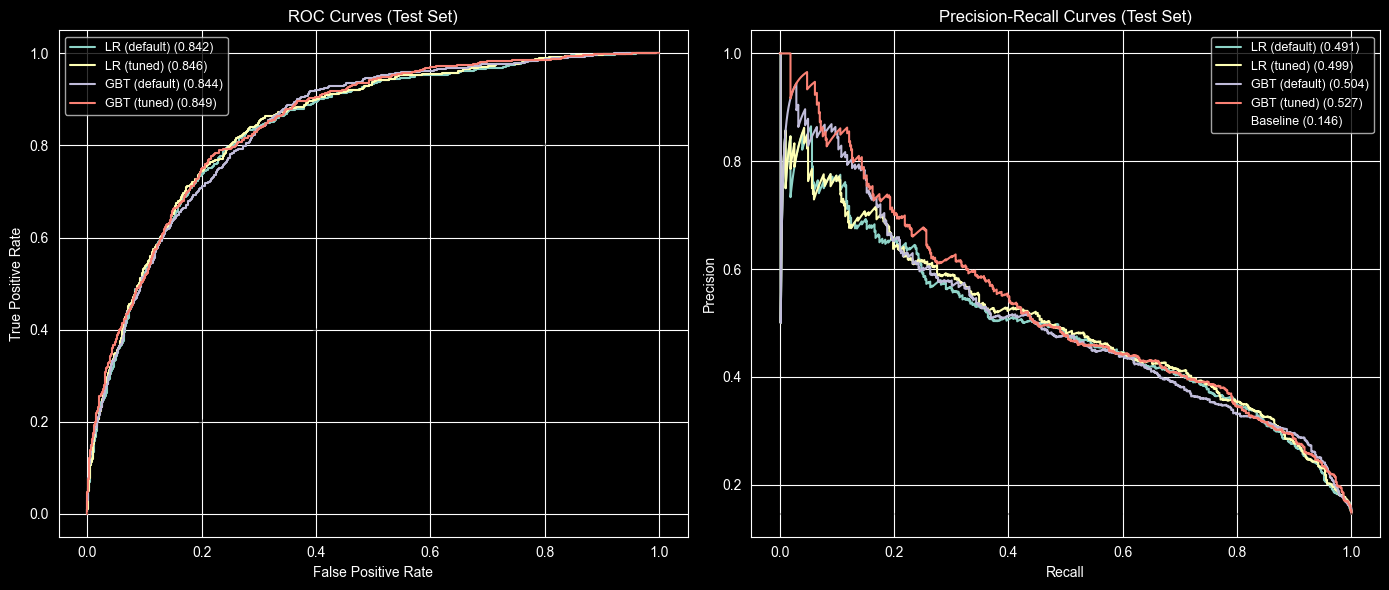

In [8]:
# ── Evaluate tuned models on val & test ──────────────────────────────────────
from sklearn.metrics import average_precision_score, precision_recall_curve

lr_best  = lr_gs.best_estimator_
gbt_best = gbt_gs.best_estimator_

results = {}
print(f"{'Model':15s}  {'Val AUROC':>10s}  {'Val AUPRC':>10s}  {'Test AUROC':>11s}  {'Test AUPRC':>11s}")
print("-" * 65)
for name, model in [("LR (tuned)", lr_best), ("GBT (tuned)", gbt_best)]:
    p_val  = model.predict_proba(X_v)[:, 1]
    p_test = model.predict_proba(X_te)[:, 1]
    auc_val  = roc_auc_score(y_v, p_val)
    auc_test = roc_auc_score(y_te, p_test)
    prc_val  = average_precision_score(y_v, p_val)
    prc_test = average_precision_score(y_te, p_test)
    results[name] = {"val_auc": auc_val, "test_auc": auc_test,
                     "val_prc": prc_val, "test_prc": prc_test, "proba_test": p_test}
    print(f"{name:15s}  {auc_val:10.4f}  {prc_val:10.4f}  {auc_test:11.4f}  {prc_test:11.4f}")

# ── ROC & PRC comparison: default vs tuned ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

curves = [
    ("LR (default)",  lr_proba_test),
    ("LR (tuned)",    results["LR (tuned)"]["proba_test"]),
    ("GBT (default)", gbt_proba_test),
    ("GBT (tuned)",   results["GBT (tuned)"]["proba_test"]),
]

# ROC
for name, proba in curves:
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    axes[0].plot(fpr, tpr, label=f"{name} ({auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (Test Set)")
axes[0].legend(fontsize=9)

# PRC
baseline_prc = y_te.mean()
for name, proba in curves:
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ap = average_precision_score(y_te, proba)
    axes[1].plot(rec, prec, label=f"{name} ({ap:.3f})")
axes[1].axhline(baseline_prc, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline_prc:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (Test Set)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2.3 Feature Engineering

The simple last-value features only use the final hour of each variable, discarding 47 hours of temporal information. We engineer additional features to capture:

- **Last value**: the most recent measurement (already used above)
- **First value**: admission baseline
- **First–last delta**: trajectory over the full 48h stay
- **Min / Max**: worst values during the stay
- **Mean / Std**: average level and variability (instability signals)
- **Missingness count**: number of hours with an actual measurement (sicker patients get tested more often)

In [9]:
# ── Engineered Feature Extraction ────────────────────────────────────────────
# Use scaled/imputed data for all features EXCEPT std, which is computed on raw (pre-imputation) data to reflect true variability.

# Raw hourly grids (before imputation & scaling) for std calculation
df_train_raw = pd.read_parquet("processed/set_a.parquet")
df_val_raw   = pd.read_parquet("processed/set_b.parquet")
df_test_raw  = pd.read_parquet("processed/set_c.parquet")

def extract_engineered_features(df_scaled, df_raw):

    grp = df_scaled.groupby("RecordID")
    grp_raw = df_raw.groupby("RecordID")
    
    last  = grp[DYNAMIC_VARS].last()
    first = grp[DYNAMIC_VARS].first()
    mean  = grp[DYNAMIC_VARS].mean()
    vmin  = grp[DYNAMIC_VARS].min()
    vmax  = grp[DYNAMIC_VARS].max()
    delta = last - first
    std = grp_raw[DYNAMIC_VARS].std().fillna(0)
    
#New column names
    last  = last.rename(columns={c: f"{c}_last" for c in DYNAMIC_VARS})
    first = first.rename(columns={c: f"{c}_first" for c in DYNAMIC_VARS})
    mean  = mean.rename(columns={c: f"{c}_mean" for c in DYNAMIC_VARS})
    std   = std.rename(columns={c: f"{c}_std" for c in DYNAMIC_VARS})
    vmin  = vmin.rename(columns={c: f"{c}_min" for c in DYNAMIC_VARS})
    vmax  = vmax.rename(columns={c: f"{c}_max" for c in DYNAMIC_VARS})
    delta = delta.rename(columns={c: f"{c}_delta" for c in DYNAMIC_VARS})
    
    statics = grp[STATIC_VARS].first()
    labels  = grp["In-hospital_death"].first().reset_index()
    
    features = pd.concat([last, first, mean, std, vmin, vmax, delta, statics], axis=1)
    features = features.reset_index()
    
    return features, labels

X_train_eng, y_train_eng = extract_engineered_features(df_train, df_train_raw)
X_val_eng,   y_val_eng   = extract_engineered_features(df_val,   df_val_raw)
X_test_eng,  y_test_eng  = extract_engineered_features(df_test,  df_test_raw)

ENG_FEATURES = [c for c in X_train_eng.columns if c != "RecordID"]

print(f"Engineered feature count: {len(ENG_FEATURES)}")
print(f"  = 37 dynamic × 7 aggregations + {len(STATIC_VARS)} static = {37*7 + len(STATIC_VARS)}")
print(f"Train: {X_train_eng.shape}, Val: {X_val_eng.shape}, Test: {X_test_eng.shape}")
print(f"\nStd source: raw (pre-imputation) data")
print(f"All other features: scaled/imputed data")
print(f"\nNaN count: {X_train_eng[ENG_FEATURES].isna().sum().sum()}")
X_train_eng.head()

Engineered feature count: 263
  = 37 dynamic × 7 aggregations + 4 static = 263
Train: (4000, 264), Val: (4000, 264), Test: (4000, 264)

Std source: raw (pre-imputation) data
All other features: scaled/imputed data

NaN count: 0


,RecordID,ALP_last,ALT_last,AST_last,Albumin_last,BUN_last,Bilirubin_last,Cholesterol_last,Creatinine_last,DiasABP_last,...,TroponinI_delta,TroponinT_delta,Urine_delta,WBC_delta,Weight_delta,pH_delta,Age,Gender,Height,StaticWeight
0,132539,0.666667,0.222222,-0.695652,-0.218305,-0.6875,-0.333333,-0.374775,-0.333333,0.279561,...,0.0,0.0,1.818182,-0.245894,0.000000,0.000000,-0.583612,0.0,-0.451583,-2.437098
1,132540,-0.518519,-0.055556,0.217391,-0.446695,0.1250,0.666667,-0.361386,0.666667,-0.704886,...,0.0,0.0,1.454545,0.215157,0.240637,-0.561344,0.669324,1.0,0.353422,0.139491
2,132541,1.074074,2.555556,5.217391,-1.588648,-1.0000,7.000000,1.687192,-1.000000,0.853822,...,0.0,0.0,-0.590909,-0.737681,0.000000,1.871147,-1.153129,0.0,-0.451583,-0.637229
3,132543,1.074074,-0.944444,-1.260870,3.207554,-0.5625,-1.666667,-0.160545,-0.333333,0.033449,...,0.0,0.0,4.181818,-0.353472,0.000000,0.000000,0.213711,1.0,0.670353,0.233071
4,132545,0.037037,-0.166667,-0.130435,0.695258,0.3750,-0.666667,0.107243,0.166667,-0.294700,...,0.0,0.0,0.181818,-1.121890,0.000000,0.000000,1.352744,0.0,-0.939658,-2.437098


In [10]:
# ── Scale engineered features (fit on train only) ────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler_eng = StandardScaler()
X_tr_eng = scaler_eng.fit_transform(X_train_eng[ENG_FEATURES])
X_v_eng  = scaler_eng.transform(X_val_eng[ENG_FEATURES])
X_te_eng = scaler_eng.transform(X_test_eng[ENG_FEATURES])

y_tr_eng = y_train_eng["In-hospital_death"].values
y_v_eng  = y_val_eng["In-hospital_death"].values
y_te_eng = y_test_eng["In-hospital_death"].values

print(f"Scaled feature matrices — Train: {X_tr_eng.shape}, Val: {X_v_eng.shape}, Test: {X_te_eng.shape}")

Scaled feature matrices — Train: (4000, 263), Val: (4000, 263), Test: (4000, 263)


In [11]:
# ── Train LR & GBT on engineered features with GridSearchCV ──────────────────

# LR
lr_gs_eng = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=5000, random_state=42),
    param_grid={
        "C": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0, 0.25, 0.5, 0.75, 1.0],
        "class_weight": ["balanced", None],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
lr_gs_eng.fit(X_tr_eng, y_tr_eng)
print(f"\nLR best params: {lr_gs_eng.best_params_}")
print(f"LR best CV AUROC: {lr_gs_eng.best_score_:.4f}")

# GBT
gbt_gs_eng = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 500],
        "max_depth": [ 5, 6],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8],
        "min_samples_leaf": [10, 15],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
gbt_gs_eng.fit(X_tr_eng, y_tr_eng)
print(f"\nGBT best params: {gbt_gs_eng.best_params_}")
print(f"GBT best CV AUROC: {gbt_gs_eng.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ferdinandunterhuber/ETH/Machine-Learning-for-Health-Care/


LR best params: {'C': 0.01, 'class_weight': 'balanced', 'l1_ratio': 0.25}
LR best CV AUROC: 0.8407
Fitting 5 folds for each of 108 candidates, totalling 540 fits

GBT best params: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 500, 'subsample': 0.8}
GBT best CV AUROC: 0.8610


Model                           Val AUROC  Val AUPRC  Test AUROC  Test AUPRC
---------------------------------------------------------------------------
LR  (simple, tuned)                0.8506     0.5276      0.8460      0.4986
LR  (engineered)                   0.8623     0.5470      0.8606      0.5289
GBT (simple, tuned)                0.8502     0.5204      0.8495      0.5270
GBT (engineered)                   0.8623     0.5378      0.8608      0.5531


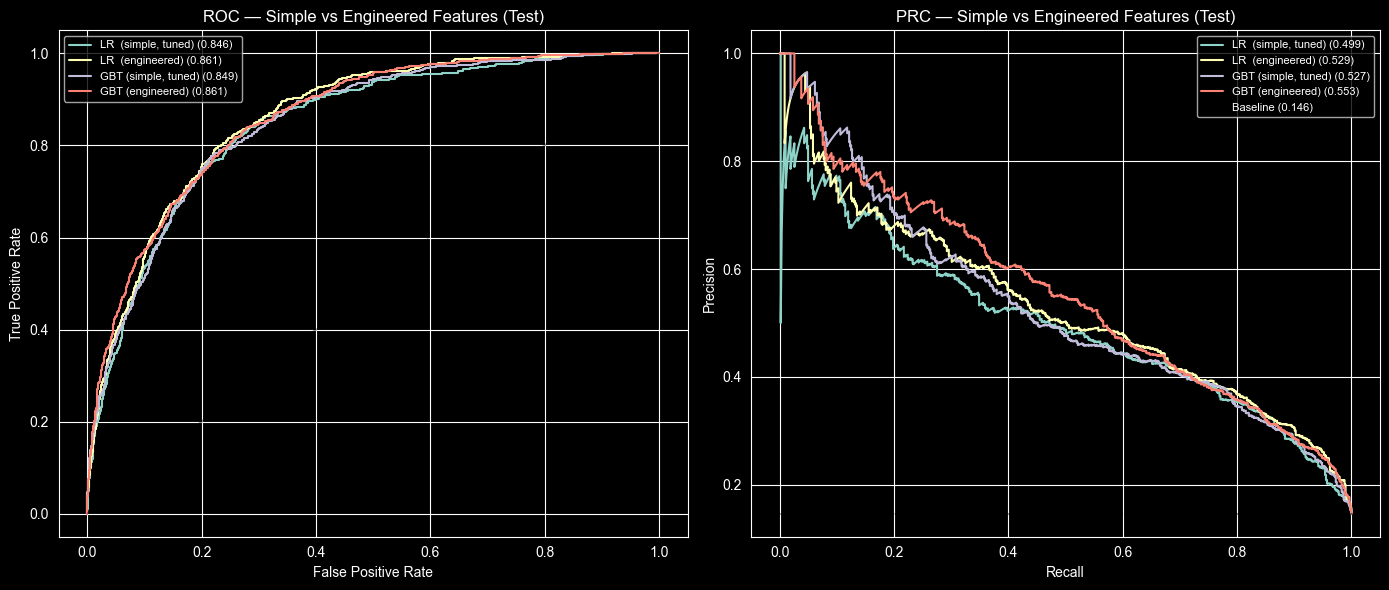

In [12]:
# ── Compare: simple features vs engineered features ──────────────────────────
lr_eng  = lr_gs_eng.best_estimator_
gbt_eng = gbt_gs_eng.best_estimator_

print(f"{'Model':<30s} {'Val AUROC':>10s} {'Val AUPRC':>10s} {'Test AUROC':>11s} {'Test AUPRC':>11s}")
print("-" * 75)

all_curves = []
for name, model, Xv, Xte, yv, yte in [
    ("LR  (simple, tuned)",  lr_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("LR  (engineered)",     lr_eng,                  X_v_eng, X_te_eng, y_v_eng, y_te_eng),
    ("GBT (simple, tuned)",  gbt_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("GBT (engineered)",     gbt_eng,                 X_v_eng, X_te_eng, y_v_eng, y_te_eng),
]:
    pv  = model.predict_proba(Xv)[:, 1]
    pt  = model.predict_proba(Xte)[:, 1]
    auc_v = roc_auc_score(yv, pv)
    auc_t = roc_auc_score(yte, pt)
    prc_v = average_precision_score(yv, pv)
    prc_t = average_precision_score(yte, pt)
    print(f"{name:<30s} {auc_v:10.4f} {prc_v:10.4f} {auc_t:11.4f} {prc_t:11.4f}")
    all_curves.append((name, pt, yte))

# ── ROC & PRC plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, pt, yte in all_curves:
    fpr, tpr, _ = roc_curve(yte, pt)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yte, pt):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — Simple vs Engineered Features (Test)")
axes[0].legend(fontsize=8)

baseline = y_te_eng.mean()
for name, pt, yte in all_curves:
    prec, rec, _ = precision_recall_curve(yte, pt)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(yte, pt):.3f})")
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PRC — Simple vs Engineered Features (Test)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Feature Selection via ElasticNet

The tuned LR with L1/ElasticNet regularization shrinks unimportant coefficients to zero. We extract the non-zero features and retrain both LR and GBT on only those — reducing noise and potentially improving generalization.

In [13]:
# ── Extract non-zero features from ElasticNet LR ─────────────────────────────
lr_coefs = lr_eng.coef_[0]
nonzero_mask = lr_coefs != 0
selected_features = [f for f, m in zip(ENG_FEATURES, nonzero_mask) if m]

print(f"ElasticNet LR selected {len(selected_features)} / {len(ENG_FEATURES)} features")
print(f"Dropped {len(ENG_FEATURES) - len(selected_features)} features (coef = 0)\n")

# Show top features by absolute coefficient
coef_series = pd.Series(lr_coefs, index=ENG_FEATURES)
top_features = coef_series[nonzero_mask].abs().sort_values(ascending=False).head(20)
print("Top 20 features by |coefficient|:")
for feat, val in top_features.items():
    sign = "+" if coef_series[feat] > 0 else "-"
    print(f"  {sign} {feat:<30s}  |coef| = {val:.4f}")

ElasticNet LR selected 106 / 263 features
Dropped 157 features (coef = 0)

Top 20 features by |coefficient|:
  - GCS_last                        |coef| = 0.4316
  - GCS_delta                       |coef| = 0.2332
  - GCS_std                         |coef| = 0.2277
  + BUN_min                         |coef| = 0.2177
  - GCS_mean                        |coef| = 0.1760
  + Age                             |coef| = 0.1683
  - Temp_mean                       |coef| = 0.1623
  + BUN_last                        |coef| = 0.1507
  + pH_mean                         |coef| = 0.1392
  - PaO2_max                        |coef| = 0.1275
  - Na_min                          |coef| = 0.1226
  + Bilirubin_delta                 |coef| = 0.1158
  - MechVent_max                    |coef| = 0.1135
  + ALP_min                         |coef| = 0.1100
  + SysABP_first                    |coef| = 0.1067
  + Lactate_delta                   |coef| = 0.1038
  + RespRate_min                    |coef| = 0.0988
  - Dia

In [4]:
# ── Retrain LR & GBT on selected features only ──────────────────────────────
sel_idx = [ENG_FEATURES.index(f) for f in selected_features]

X_tr_sel = X_tr_eng[:, sel_idx]
X_v_sel  = X_v_eng[:, sel_idx]
X_te_sel = X_te_eng[:, sel_idx]

# LR on selected features
lr_gs_sel = GridSearchCV(
    LogisticRegression(solver="saga", max_iter=5000, random_state=42),
    param_grid={
        "C": [0.001, 0.01, 0.1],
        "l1_ratio": [0, 0.25, 0.5, 0.75, 1.0],
        "class_weight": ["balanced", None],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
lr_gs_sel.fit(X_tr_sel, y_tr_eng)

# GBT on selected features
gbt_gs_sel = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        "n_estimators": [100, 200, 500],
        "max_depth": [ 4, 5],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.8],
        "min_samples_leaf": [10, 20],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1,
)
gbt_gs_sel.fit(X_tr_sel, y_tr_eng)

print(f"\nLR  (selected) best CV AUROC: {lr_gs_sel.best_score_:.4f}  params: {lr_gs_sel.best_params_}")
print(f"GBT (selected) best CV AUROC: {gbt_gs_sel.best_score_:.4f}  params: {gbt_gs_sel.best_params_}")

NameError: name 'selected_features' is not defined

Model                                Val AUROC  Val AUPRC  Test AUROC  Test AUPRC
--------------------------------------------------------------------------------
LR  (simple, 41 feat)                   0.8506     0.5276      0.8460      0.4986
LR  (engineered, all feat)              0.8623     0.5470      0.8606      0.5289
GBT (simple, 41 feat)                   0.8502     0.5204      0.8495      0.5270
GBT (engineered, all feat)              0.8623     0.5378      0.8608      0.5531
GBT (engineered, selected)              0.8639     0.5573      0.8612      0.5559


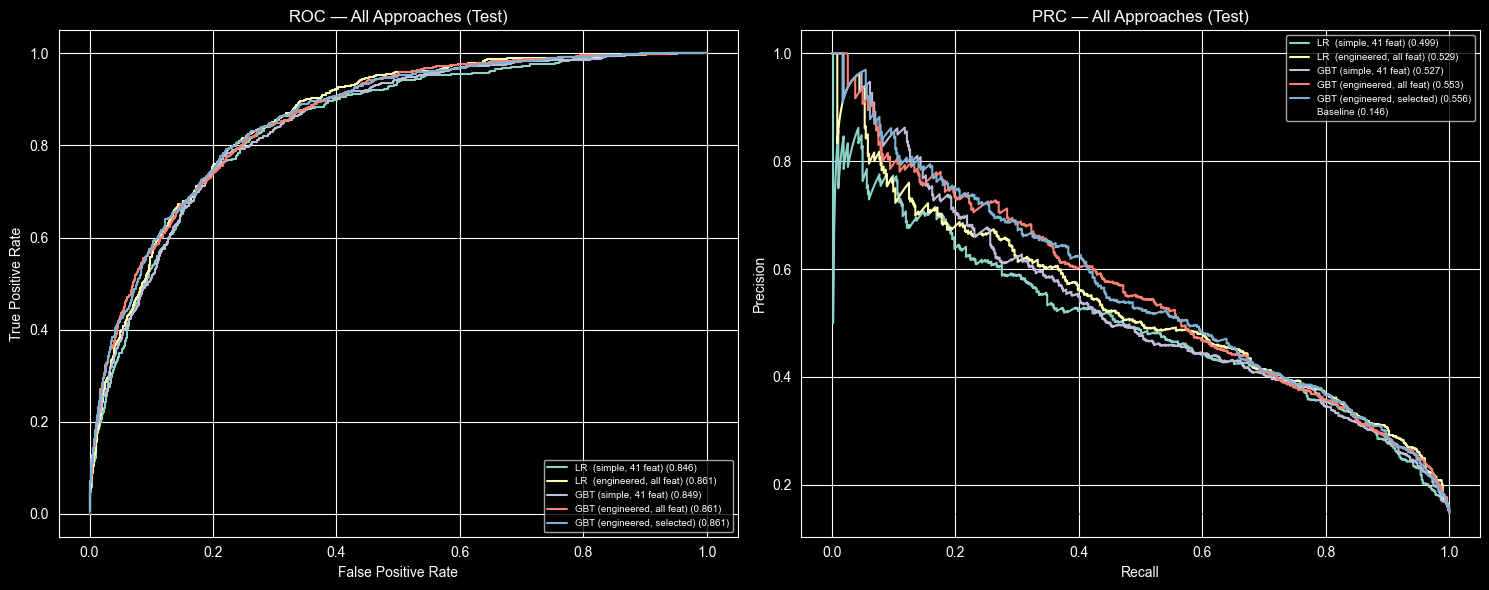

In [19]:
# ── Final comparison: all approaches ─────────────────────────────────────────
gbt_sel = gbt_gs_sel.best_estimator_

print(f"{'Model':<35s} {'Val AUROC':>10s} {'Val AUPRC':>10s} {'Test AUROC':>11s} {'Test AUPRC':>11s}")
print("-" * 80)

final_curves = []
for name, model, Xv, Xte, yv, yte in [
    ("LR  (simple, 41 feat)",        lr_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("LR  (engineered, all feat)",    lr_eng,                  X_v_eng, X_te_eng, y_v_eng, y_te_eng),
    ("GBT (simple, 41 feat)",        gbt_gs.best_estimator_,  X_v,     X_te,     y_v,     y_te),
    ("GBT (engineered, all feat)",   gbt_eng,                 X_v_eng, X_te_eng, y_v_eng, y_te_eng),
    ("GBT (engineered, selected)",   gbt_sel,                 X_v_sel, X_te_sel, y_v_eng, y_te_eng),
]:
    pv  = model.predict_proba(Xv)[:, 1]
    pt  = model.predict_proba(Xte)[:, 1]
    auc_v = roc_auc_score(yv, pv)
    auc_t = roc_auc_score(yte, pt)
    prc_v = average_precision_score(yv, pv)
    prc_t = average_precision_score(yte, pt)
    print(f"{name:<35s} {auc_v:10.4f} {prc_v:10.4f} {auc_t:11.4f} {prc_t:11.4f}")
    final_curves.append((name, pt, yte))

# ── ROC & PRC plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, pt, yte in final_curves:
    fpr, tpr, _ = roc_curve(yte, pt)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yte, pt):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC — All Approaches (Test)")
axes[0].legend(fontsize=7, loc="lower right")

baseline = y_te_eng.mean()
for name, pt, yte in final_curves:
    prec, rec, _ = precision_recall_curve(yte, pt)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(yte, pt):.3f})")
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PRC — All Approaches (Test)")
axes[1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

## 2.2 RNN

Dynamic  — Train: torch.Size([4000, 49, 37])  Val: torch.Size([4000, 49, 37])  Test: torch.Size([4000, 49, 37])
Static   — Train: torch.Size([4000, 4])   Val: torch.Size([4000, 4])   Test: torch.Size([4000, 4])
Positive rate: 0.139
Device: mps
MortalityLSTM(
  (lstm): LSTM(41, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 27,457
Epoch   1  loss=1.1217  val_AUROC=0.8054  val_AUPRC=0.3766  lr=1.0e-03
Epoch   2  loss=0.9257  val_AUROC=0.8358  val_AUPRC=0.4717  lr=1.0e-03
Epoch   3  loss=0.8308  val_AUROC=0.8459  val_AUPRC=0.4859  lr=1.0e-03
Epoch   5  loss=0.7297  val_AUROC=0.8467  val_AUPRC=0.4819  lr=1.0e-03
Epoch  10  loss=0.5365  val_AUROC=0.8355  val_AUPRC=0.4641  lr=5.0e-04
Epoch  15  loss=0.4224  val_AUROC=0.8212  val_AUPRC=0.4381  lr=2.5e-04
Early stopping at epoch 15

LSTM (unidirectional)           Val AUROC=0.8467  Test AUROC=0.8408  Test AUPRC=0.4762


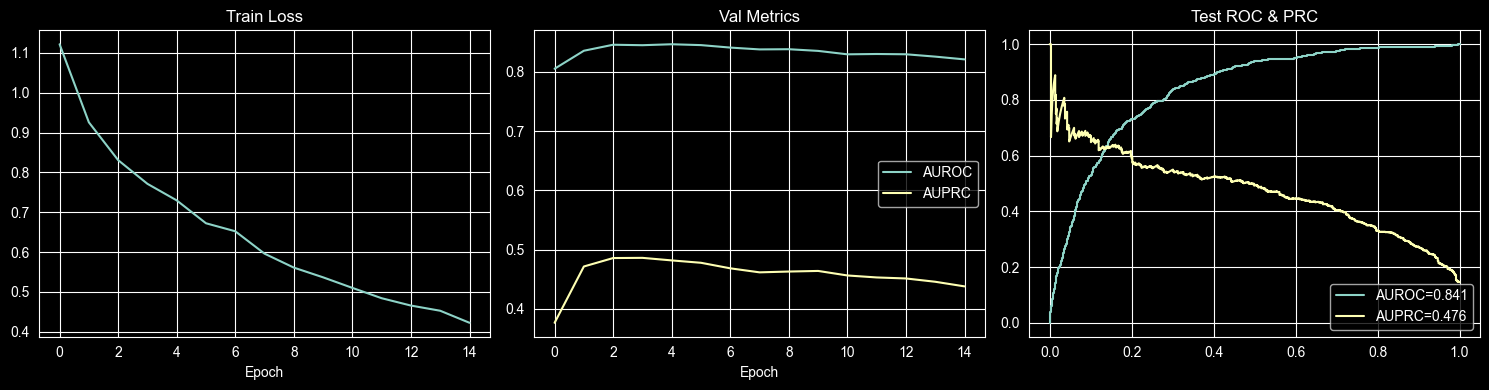

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# ── 1. Reshape parquet → 3-D tensors ────────────────────────────────────────
# Dynamic: (N, 49, 37)  — 49 time steps, 37 features
# Static:  (N, 4)       — Age, Gender, Height, StaticWeight (constant per patient)

def df_to_tensors(df, dynamic_vars, static_vars, n_steps=49):
    df = df.sort_values(["RecordID", "hour"])
    n_patients = df["RecordID"].nunique()
    X_dyn  = torch.tensor(df[dynamic_vars].values.reshape(n_patients, n_steps, -1), dtype=torch.float32)
    X_stat = torch.tensor(df.groupby("RecordID")[static_vars].first().values, dtype=torch.float32)
    y      = torch.tensor(df.groupby("RecordID")["In-hospital_death"].first().values, dtype=torch.float32)
    return X_dyn, X_stat, y

X_dyn_tr, X_stat_tr, y_tr_rnn = df_to_tensors(df_train, DYNAMIC_VARS, STATIC_VARS)
X_dyn_v,  X_stat_v,  y_v_rnn  = df_to_tensors(df_val,   DYNAMIC_VARS, STATIC_VARS)
X_dyn_te, X_stat_te, y_te_rnn = df_to_tensors(df_test,  DYNAMIC_VARS, STATIC_VARS)

print(f"Dynamic  — Train: {X_dyn_tr.shape}  Val: {X_dyn_v.shape}  Test: {X_dyn_te.shape}")
print(f"Static   — Train: {X_stat_tr.shape}   Val: {X_stat_v.shape}   Test: {X_stat_te.shape}")
print(f"Positive rate: {y_tr_rnn.mean():.3f}")

# ── 2. DataLoaders ──────────────────────────────────────────────────────────
BATCH = 128
train_dl = DataLoader(TensorDataset(X_dyn_tr, X_stat_tr, y_tr_rnn), batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_dyn_v,  X_stat_v,  y_v_rnn),  batch_size=BATCH)
test_dl  = DataLoader(TensorDataset(X_dyn_te, X_stat_te, y_te_rnn), batch_size=BATCH)

# ── 3. LSTM model (static features fused after LSTM) ────────────────────────
class MortalityLSTM(nn.Module):
    def __init__(self, input_dim=37, static_dim=4, hidden_dim=64, n_layers=1, dropout=0.5):
        super().__init__()
        self.static_dim = static_dim
        # Static features are concatenated to every time step
        self.lstm = nn.LSTM(
            input_size=input_dim + static_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x_dyn, x_stat):
        # x_dyn: (batch, 49, 37),  x_stat: (batch, 4)
        # Broadcast static features to every time step
        x_stat_exp = x_stat.unsqueeze(1).expand(-1, x_dyn.size(1), -1)  # (batch, 49, 4)
        x = torch.cat([x_dyn, x_stat_exp], dim=2)  # (batch, 49, 41)
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]                 # (batch, hidden)
        return self.head(last_hidden).squeeze(-1)

device = torch.device("mps" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = MortalityLSTM().to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── 4. Training ─────────────────────────────────────────────────────────────
pos_weight = torch.tensor([(y_tr_rnn == 0).sum() / (y_tr_rnn == 1).sum()]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 50
best_val_auc = 0
patience_ctr, patience_limit = 0, 10
history = {"train_loss": [], "val_auc": [], "val_prc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for xd, xs, yb in train_dl:
        xd, xs, yb = xd.to(device), xs.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xd, xs), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(xd)
    avg_loss = total_loss / len(train_dl.dataset)

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xd, xs, yb in val_dl:
            preds.append(torch.sigmoid(model(xd.to(device), xs.to(device))).cpu())
            labels.append(yb)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    val_auc = roc_auc_score(labels, preds)
    val_prc = average_precision_score(labels, preds)
    scheduler.step(val_auc)

    history["train_loss"].append(avg_loss)
    history["val_auc"].append(val_auc)
    history["val_prc"].append(val_prc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or patience_ctr == 0:
        print(f"Epoch {epoch:3d}  loss={avg_loss:.4f}  val_AUROC={val_auc:.4f}  val_AUPRC={val_prc:.4f}  lr={optimizer.param_groups[0]['lr']:.1e}")

    if patience_ctr >= patience_limit:
        print(f"Early stopping at epoch {epoch}")
        break

# ── 5. Test evaluation ──────────────────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()
preds_test, labels_test = [], []
with torch.no_grad():
    for xd, xs, yb in test_dl:
        preds_test.append(torch.sigmoid(model(xd.to(device), xs.to(device))).cpu())
        labels_test.append(yb)
preds_test  = torch.cat(preds_test).numpy()
labels_test = torch.cat(labels_test).numpy()

test_auc = roc_auc_score(labels_test, preds_test)
test_prc = average_precision_score(labels_test, preds_test)
print(f"\n{'LSTM (unidirectional)':<30s}  Val AUROC={best_val_auc:.4f}  Test AUROC={test_auc:.4f}  Test AUPRC={test_prc:.4f}")

# ── 6. Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["train_loss"]); axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch")
axes[1].plot(history["val_auc"], label="AUROC"); axes[1].plot(history["val_prc"], label="AUPRC")
axes[1].set_title("Val Metrics"); axes[1].set_xlabel("Epoch"); axes[1].legend()
fpr, tpr, _ = roc_curve(labels_test, preds_test)
prec, rec, _ = precision_recall_curve(labels_test, preds_test)
axes[2].plot(fpr, tpr, label=f"AUROC={test_auc:.3f}")
axes[2].plot(rec, prec, label=f"AUPRC={test_prc:.3f}")
axes[2].set_title("Test ROC & PRC"); axes[2].legend()
plt.tight_layout(); plt.show()

MortalityBiLSTM(
  (lstm): LSTM(41, 64, batch_first=True, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=1, bias=True)
  )
)
Parameters: 54,913
Epoch   1  loss=1.1145  val_AUROC=0.8079  val_AUPRC=0.4094  lr=1.0e-03
Epoch   2  loss=0.9143  val_AUROC=0.8356  val_AUPRC=0.4430  lr=1.0e-03
Epoch   3  loss=0.8231  val_AUROC=0.8446  val_AUPRC=0.4730  lr=1.0e-03
Epoch   4  loss=0.7564  val_AUROC=0.8493  val_AUPRC=0.4797  lr=1.0e-03
Epoch   5  loss=0.7042  val_AUROC=0.8450  val_AUPRC=0.4713  lr=1.0e-03
Epoch  10  loss=0.4776  val_AUROC=0.8309  val_AUPRC=0.4682  lr=5.0e-04
Early stopping at epoch 14

Model                           Val AUROC  Test AUROC  Test AUPRC
-----------------------------------------------------------------
LSTM (unidirectional)              0.8473      0.8393      0.4748
LSTM (bidirectional)               0.8493      0.8399      0.4667


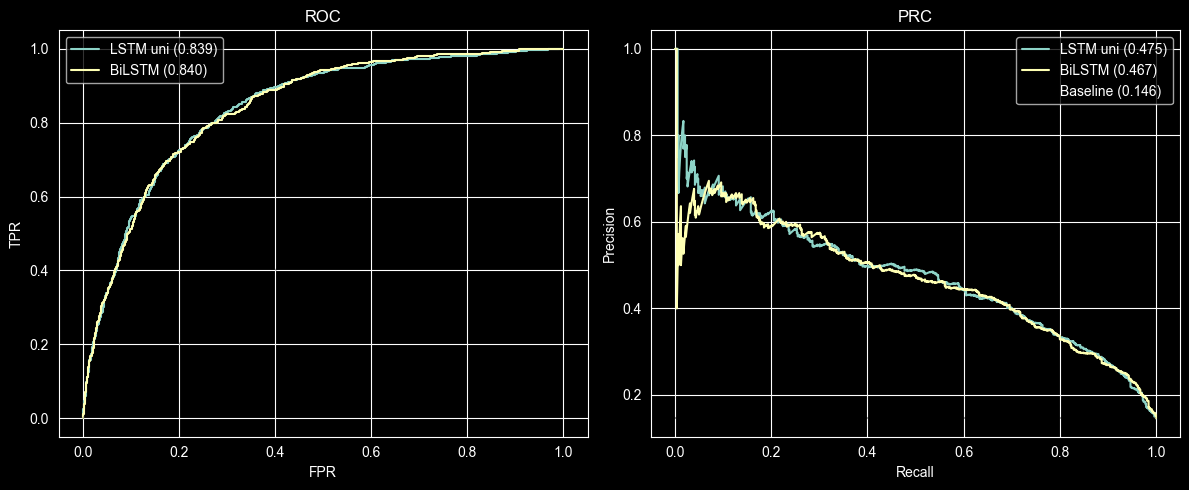

In [10]:
# ── Bidirectional LSTM ────────────────────────────────────────────────────────

class MortalityBiLSTM(nn.Module):
    def __init__(self, input_dim=37, static_dim=4, hidden_dim=64, n_layers=1, dropout=0.5):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(
            input_size=input_dim + static_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.Linear(2 * hidden_dim, 1),
        )

    def forward(self, x_dyn, x_stat):
        # x_dyn: (batch, 49, 37),  x_stat: (batch, 4)
        x_stat_exp = x_stat.unsqueeze(1).expand(-1, x_dyn.size(1), -1)  # (batch, 49, 4)
        x = torch.cat([x_dyn, x_stat_exp], dim=2)  # (batch, 49, 41)
        _, (h_n, _) = self.lstm(x)
        fwd = h_n[-2]   # last layer, forward
        bwd = h_n[-1]   # last layer, backward
        combined = torch.cat([fwd, bwd], dim=1)  # (batch, 2*hidden)
        return self.head(combined).squeeze(-1)

bi_model = MortalityBiLSTM().to(device)
print(bi_model)
print(f"Parameters: {sum(p.numel() for p in bi_model.parameters()):,}")

# ── Training ────────────────────────────────────────────────────────────────
bi_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
bi_optimizer = torch.optim.Adam(bi_model.parameters(), lr=1e-3, weight_decay=1e-3)
bi_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(bi_optimizer, patience=5, factor=0.5)

best_bi_auc = 0
bi_patience, bi_patience_limit = 0, 10
bi_history = {"train_loss": [], "val_auc": [], "val_prc": []}

for epoch in range(1, EPOCHS + 1):
    bi_model.train()
    total_loss = 0
    for xd, xs, yb in train_dl:
        xd, xs, yb = xd.to(device), xs.to(device), yb.to(device)
        bi_optimizer.zero_grad()
        loss = bi_criterion(bi_model(xd, xs), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bi_model.parameters(), 1.0)
        bi_optimizer.step()
        total_loss += loss.item() * len(xd)
    avg_loss = total_loss / len(train_dl.dataset)

    bi_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xd, xs, yb in val_dl:
            preds.append(torch.sigmoid(bi_model(xd.to(device), xs.to(device))).cpu())
            labels.append(yb)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    val_auc = roc_auc_score(labels, preds)
    val_prc = average_precision_score(labels, preds)
    bi_scheduler.step(val_auc)

    bi_history["train_loss"].append(avg_loss)
    bi_history["val_auc"].append(val_auc)
    bi_history["val_prc"].append(val_prc)

    if val_auc > best_bi_auc:
        best_bi_auc = val_auc
        best_bi_state = {k: v.cpu().clone() for k, v in bi_model.state_dict().items()}
        bi_patience = 0
    else:
        bi_patience += 1

    if epoch % 5 == 0 or bi_patience == 0:
        print(f"Epoch {epoch:3d}  loss={avg_loss:.4f}  val_AUROC={val_auc:.4f}  val_AUPRC={val_prc:.4f}  lr={bi_optimizer.param_groups[0]['lr']:.1e}")

    if bi_patience >= bi_patience_limit:
        print(f"Early stopping at epoch {epoch}")
        break

# ── Test evaluation ─────────────────────────────────────────────────────────
bi_model.load_state_dict(best_bi_state)
bi_model.eval()
bi_preds_test, bi_labels_test = [], []
with torch.no_grad():
    for xd, xs, yb in test_dl:
        bi_preds_test.append(torch.sigmoid(bi_model(xd.to(device), xs.to(device))).cpu())
        bi_labels_test.append(yb)
bi_preds_test  = torch.cat(bi_preds_test).numpy()
bi_labels_test = torch.cat(bi_labels_test).numpy()

bi_test_auc = roc_auc_score(bi_labels_test, bi_preds_test)
bi_test_prc = average_precision_score(bi_labels_test, bi_preds_test)

print(f"\n{'Model':<30s} {'Val AUROC':>10s} {'Test AUROC':>11s} {'Test AUPRC':>11s}")
print("-" * 65)
print(f"{'LSTM (unidirectional)':<30s} {best_val_auc:10.4f} {test_auc:11.4f} {test_prc:11.4f}")
print(f"{'LSTM (bidirectional)':<30s} {best_bi_auc:10.4f} {bi_test_auc:11.4f} {bi_test_prc:11.4f}")

# ── Comparison plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
for name, pt, yt in [("LSTM uni", preds_test, labels_test), ("BiLSTM", bi_preds_test, bi_labels_test)]:
    fpr, tpr, _ = roc_curve(yt, pt)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yt, pt):.3f})")
axes[0].plot([0,1],[0,1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC"); axes[0].legend()

# PRC
baseline = y_te_rnn.mean().item()
for name, pt, yt in [("LSTM uni", preds_test, labels_test), ("BiLSTM", bi_preds_test, bi_labels_test)]:
    prec, rec, _ = precision_recall_curve(yt, pt)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(yt, pt):.3f})")
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PRC"); axes[1].legend()
plt.tight_layout(); plt.show()

## 2.3 Transformer

MortalityTransformer(
  (input_proj): Linear(in_features=41, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (dropout): Dropout(p=0.3, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (head): Linear(in_features=64, out_features=1, bias=True)
)
Parameters: 69,761
Epoch   1  loss=1.1146  val_AUROC=0.7774  val_AUPR

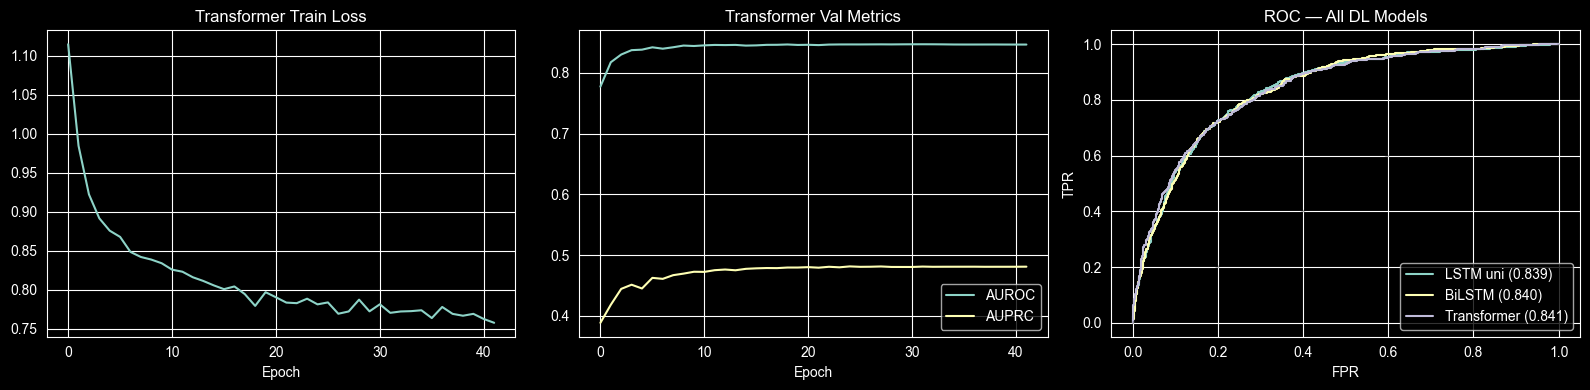

In [11]:
# ── Transformer for Mortality Prediction ──────────────────────────────────────
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 0:
            pe[:, 1::2] = torch.cos(position * div_term)
        else:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MortalityTransformer(nn.Module):
    def __init__(self, input_dim=37, static_dim=4, d_model=64, nhead=4,
                 n_layers=2, dim_ff=128, dropout=0.3):
        super().__init__()
        # Project input features to d_model
        self.input_proj = nn.Linear(input_dim + static_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=50)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Learnable [CLS] token for classification
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.head = nn.Linear(d_model, 1)

    def forward(self, x_dyn, x_stat):
        # x_dyn: (batch, 49, 37), x_stat: (batch, 4)
        B, T, _ = x_dyn.shape

        # Concat static features at every time step
        x_stat_exp = x_stat.unsqueeze(1).expand(-1, T, -1)  # (B, 49, 4)
        x = torch.cat([x_dyn, x_stat_exp], dim=2)           # (B, 49, 41)

        # Project to d_model and add positional encoding
        x = self.dropout(self.pos_enc(self.input_proj(x)))   # (B, 49, d_model)

        # Prepend [CLS] token
        cls = self.cls_token.expand(B, -1, -1)               # (B, 1, d_model)
        x = torch.cat([cls, x], dim=1)                       # (B, 50, d_model)

        # Transformer encoder
        x = self.transformer(x)                              # (B, 50, d_model)

        # Classify from [CLS] token
        return self.head(x[:, 0]).squeeze(-1)

tx_model = MortalityTransformer().to(device)
print(tx_model)
print(f"Parameters: {sum(p.numel() for p in tx_model.parameters()):,}")

# ── Training ────────────────────────────────────────────────────────────────
tx_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
tx_optimizer = torch.optim.Adam(tx_model.parameters(), lr=5e-4, weight_decay=1e-3)
tx_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(tx_optimizer, patience=5, factor=0.5)

best_tx_auc = 0
tx_patience, tx_patience_limit = 0, 10
tx_history = {"train_loss": [], "val_auc": [], "val_prc": []}

for epoch in range(1, EPOCHS + 1):
    tx_model.train()
    total_loss = 0
    for xd, xs, yb in train_dl:
        xd, xs, yb = xd.to(device), xs.to(device), yb.to(device)
        tx_optimizer.zero_grad()
        loss = tx_criterion(tx_model(xd, xs), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tx_model.parameters(), 1.0)
        tx_optimizer.step()
        total_loss += loss.item() * len(xd)
    avg_loss = total_loss / len(train_dl.dataset)

    tx_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xd, xs, yb in val_dl:
            preds.append(torch.sigmoid(tx_model(xd.to(device), xs.to(device))).cpu())
            labels.append(yb)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    val_auc = roc_auc_score(labels, preds)
    val_prc = average_precision_score(labels, preds)
    tx_scheduler.step(val_auc)

    tx_history["train_loss"].append(avg_loss)
    tx_history["val_auc"].append(val_auc)
    tx_history["val_prc"].append(val_prc)

    if val_auc > best_tx_auc:
        best_tx_auc = val_auc
        best_tx_state = {k: v.cpu().clone() for k, v in tx_model.state_dict().items()}
        tx_patience = 0
    else:
        tx_patience += 1

    if epoch % 5 == 0 or tx_patience == 0:
        print(f"Epoch {epoch:3d}  loss={avg_loss:.4f}  val_AUROC={val_auc:.4f}  val_AUPRC={val_prc:.4f}  lr={tx_optimizer.param_groups[0]['lr']:.1e}")

    if tx_patience >= tx_patience_limit:
        print(f"Early stopping at epoch {epoch}")
        break

# ── Test evaluation ─────────────────────────────────────────────────────────
tx_model.load_state_dict(best_tx_state)
tx_model.eval()
tx_preds_test, tx_labels_test = [], []
with torch.no_grad():
    for xd, xs, yb in test_dl:
        tx_preds_test.append(torch.sigmoid(tx_model(xd.to(device), xs.to(device))).cpu())
        tx_labels_test.append(yb)
tx_preds_test  = torch.cat(tx_preds_test).numpy()
tx_labels_test = torch.cat(tx_labels_test).numpy()

tx_test_auc = roc_auc_score(tx_labels_test, tx_preds_test)
tx_test_prc = average_precision_score(tx_labels_test, tx_preds_test)

# ── Comparison: all deep learning models ────────────────────────────────────
print(f"\n{'Model':<30s} {'Val AUROC':>10s} {'Test AUROC':>11s} {'Test AUPRC':>11s}")
print("-" * 65)
print(f"{'LSTM (unidirectional)':<30s} {best_val_auc:10.4f} {test_auc:11.4f} {test_prc:11.4f}")
print(f"{'LSTM (bidirectional)':<30s} {best_bi_auc:10.4f} {bi_test_auc:11.4f} {bi_test_prc:11.4f}")
print(f"{'Transformer':<30s} {best_tx_auc:10.4f} {tx_test_auc:11.4f} {tx_test_prc:11.4f}")

# ── Plots ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(tx_history["train_loss"]); axes[0].set_title("Transformer Train Loss"); axes[0].set_xlabel("Epoch")
axes[1].plot(tx_history["val_auc"], label="AUROC"); axes[1].plot(tx_history["val_prc"], label="AUPRC")
axes[1].set_title("Transformer Val Metrics"); axes[1].set_xlabel("Epoch"); axes[1].legend()

# ROC & PRC for all models
all_models = [
    ("LSTM uni", preds_test, labels_test),
    ("BiLSTM", bi_preds_test, bi_labels_test),
    ("Transformer", tx_preds_test, tx_labels_test),
]
for name, pt, yt in all_models:
    fpr, tpr, _ = roc_curve(yt, pt)
    axes[2].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yt, pt):.3f})")
axes[2].plot([0,1],[0,1], "k--", alpha=0.3)
axes[2].set_xlabel("FPR"); axes[2].set_ylabel("TPR"); axes[2].set_title("ROC — All DL Models"); axes[2].legend()
plt.tight_layout(); plt.show()

In [ ]:
# ── Hyperparameter Tuning for all DL models ──────────────────────────────────
from itertools import product

def train_and_eval(model, train_dl, val_dl, device, lr, wd, epochs=50, patience_limit=10):
    """Train a model, return best val AUROC, AUPRC, and state dict."""
    pos_w = torch.tensor([(y_tr_rnn == 0).sum() / (y_tr_rnn == 1).sum()]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    best_auc, best_state, patience_ctr = 0, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for xd, xs, yb in train_dl:
            xd, xs, yb = xd.to(device), xs.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xd, xs), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for xd, xs, yb in val_dl:
                preds.append(torch.sigmoid(model(xd.to(device), xs.to(device))).cpu())
                labels.append(yb)
        preds  = torch.cat(preds).numpy()
        labels = torch.cat(labels).numpy()
        val_auc = roc_auc_score(labels, preds)
        scheduler.step(val_auc)

        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience_limit:
            break

    # Eval best model on val for AUPRC too
    model.load_state_dict(best_state)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xd, xs, yb in val_dl:
            preds.append(torch.sigmoid(model(xd.to(device), xs.to(device))).cpu())
            labels.append(yb)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    best_prc = average_precision_score(labels, preds)
    return best_auc, best_prc, best_state

# ── Hyperparameter grids ────────────────────────────────────────────────────
lstm_grid = {
    "hidden_dim": [32, 64, 128],
    "n_layers":   [1, 2],
    "dropout":    [0.3, 0.5],
    "lr":         [1e-3, 5e-4],
    "wd":         [1e-3, 1e-4],
}

transformer_grid = {
    "d_model":  [32, 64],
    "nhead":    [2, 4],
    "n_layers": [1, 2],
    "dim_ff":   [64, 128],
    "dropout":  [0.3, 0.5],
    "lr":       [5e-4, 1e-4],
    "wd":       [1e-3, 1e-4],
}

# ── Tune LSTM (unidirectional) ──────────────────────────────────────────────
print("=" * 70)
print("Tuning LSTM (unidirectional)")
print("=" * 70)
best_lstm_result = {"auc": 0}
lstm_keys = list(lstm_grid.keys())
for vals in product(*lstm_grid.values()):
    cfg = dict(zip(lstm_keys, vals))
    m = MortalityLSTM(
        hidden_dim=cfg["hidden_dim"], n_layers=cfg["n_layers"], dropout=cfg["dropout"]
    ).to(device)
    auc, prc, state = train_and_eval(m, train_dl, val_dl, device, cfg["lr"], cfg["wd"])
    print(f"  h={cfg['hidden_dim']:3d} layers={cfg['n_layers']} drop={cfg['dropout']:.1f} "
          f"lr={cfg['lr']:.0e} wd={cfg['wd']:.0e}  → AUROC={auc:.4f} AUPRC={prc:.4f}")
    if auc > best_lstm_result["auc"]:
        best_lstm_result = {"auc": auc, "prc": prc, "state": state, "cfg": cfg}

print(f"\n  Best LSTM: AUROC={best_lstm_result['auc']:.4f} AUPRC={best_lstm_result['prc']:.4f}")
print(f"  Config: {best_lstm_result['cfg']}")

# ── Tune BiLSTM ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Tuning BiLSTM")
print("=" * 70)
best_bilstm_result = {"auc": 0}
for vals in product(*lstm_grid.values()):
    cfg = dict(zip(lstm_keys, vals))
    m = MortalityBiLSTM(
        hidden_dim=cfg["hidden_dim"], n_layers=cfg["n_layers"], dropout=cfg["dropout"]
    ).to(device)
    auc, prc, state = train_and_eval(m, train_dl, val_dl, device, cfg["lr"], cfg["wd"])
    print(f"  h={cfg['hidden_dim']:3d} layers={cfg['n_layers']} drop={cfg['dropout']:.1f} "
          f"lr={cfg['lr']:.0e} wd={cfg['wd']:.0e}  → AUROC={auc:.4f} AUPRC={prc:.4f}")
    if auc > best_bilstm_result["auc"]:
        best_bilstm_result = {"auc": auc, "prc": prc, "state": state, "cfg": cfg}

print(f"\n  Best BiLSTM: AUROC={best_bilstm_result['auc']:.4f} AUPRC={best_bilstm_result['prc']:.4f}")
print(f"  Config: {best_bilstm_result['cfg']}")

# ── Tune Transformer ────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Tuning Transformer")
print("=" * 70)
best_tx_result = {"auc": 0}
tx_keys = list(transformer_grid.keys())
for vals in product(*transformer_grid.values()):
    cfg = dict(zip(tx_keys, vals))
    # nhead must divide d_model
    if cfg["d_model"] % cfg["nhead"] != 0:
        continue
    m = MortalityTransformer(
        d_model=cfg["d_model"], nhead=cfg["nhead"], n_layers=cfg["n_layers"],
        dim_ff=cfg["dim_ff"], dropout=cfg["dropout"]
    ).to(device)
    auc, prc, state = train_and_eval(m, train_dl, val_dl, device, cfg["lr"], cfg["wd"])
    print(f"  d={cfg['d_model']:3d} heads={cfg['nhead']} layers={cfg['n_layers']} ff={cfg['dim_ff']:3d} "
          f"drop={cfg['dropout']:.1f} lr={cfg['lr']:.0e} wd={cfg['wd']:.0e}  → AUROC={auc:.4f} AUPRC={prc:.4f}")
    if auc > best_tx_result["auc"]:
        best_tx_result = {"auc": auc, "prc": prc, "state": state, "cfg": cfg}

print(f"\n  Best Transformer: AUROC={best_tx_result['auc']:.4f} AUPRC={best_tx_result['prc']:.4f}")
print(f"  Config: {best_tx_result['cfg']}")

# ── Final test evaluation with best configs ─────────────────────────────────
print("\n" + "=" * 70)
print("Test set evaluation with best hyperparameters")
print("=" * 70)

results_tuned = []
for name, ModelClass, result, is_tx in [
    ("LSTM (tuned)",   MortalityLSTM,       best_lstm_result,   False),
    ("BiLSTM (tuned)", MortalityBiLSTM,     best_bilstm_result, False),
    ("Transformer (tuned)", MortalityTransformer, best_tx_result, True),
]:
    cfg = result["cfg"]
    if is_tx:
        m = ModelClass(d_model=cfg["d_model"], nhead=cfg["nhead"],
                       n_layers=cfg["n_layers"], dim_ff=cfg["dim_ff"],
                       dropout=cfg["dropout"]).to(device)
    else:
        m = ModelClass(hidden_dim=cfg["hidden_dim"], n_layers=cfg["n_layers"],
                       dropout=cfg["dropout"]).to(device)
    m.load_state_dict(result["state"])
    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xd, xs, yb in test_dl:
            preds.append(torch.sigmoid(m(xd.to(device), xs.to(device))).cpu())
            labels.append(yb)
    pt = torch.cat(preds).numpy()
    yt = torch.cat(labels).numpy()
    t_auc = roc_auc_score(yt, pt)
    t_prc = average_precision_score(yt, pt)
    results_tuned.append((name, result["auc"], t_auc, t_prc, pt, yt))

print(f"\n{'Model':<30s} {'Val AUROC':>10s} {'Test AUROC':>11s} {'Test AUPRC':>11s}")
print("-" * 65)
for name, v_auc, t_auc, t_prc, _, _ in results_tuned:
    print(f"{name:<30s} {v_auc:10.4f} {t_auc:11.4f} {t_prc:11.4f}")

# ── ROC & PRC comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
baseline = y_te_rnn.mean().item()
for name, _, _, _, pt, yt in results_tuned:
    fpr, tpr, _ = roc_curve(yt, pt)
    prec, rec, _ = precision_recall_curve(yt, pt)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(yt, pt):.3f})")
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(yt, pt):.3f})")
axes[0].plot([0,1],[0,1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC"); axes[0].legend()
axes[1].axhline(baseline, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({baseline:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PRC"); axes[1].legend()
plt.tight_layout(); plt.show()